# IsabelleGym runs analysis

This notebook processes the uploaded `runs.zip` results and focuses on **performance metrics only**.
It intentionally ignores proof success rate.

## Metrics used in the evaluation

### Big-step
The most useful metrics for whole-theory verification are:
- **Total wall-clock time** for the corpus: the clearest end-to-end batch cost.
- **Files per minute**: the easiest throughput measure to report.
- **Mean wall time per file**: average cost per theory.
- **Median wall time per file**: robust to a few unusually slow theories.
- **Client overhead per file** (server only): separates server overhead from Isabelle build time.

### Small-step
The most useful metrics for interactive verification are:
- **Total wall-clock time** for the benchmark: end-to-end cost of replaying the corpus.
- **Files per minute**: throughput at the theory level.
- **Mean startup time per file**: how expensive session or theory initialisation is.
- **Mean step elapsed time**: average responsiveness per command.
- **P95 step elapsed time**: tail latency for interactive commands.
- **Median wall time per file**: robust end-to-end theory latency.

### Scalability / reuse
For server-side small-step runs, the best metrics are:
- **Total wall-clock time** and **files per minute** as worker count changes.
- **Mean startup time per file** to show the effect of reuse.
- **Mean step elapsed time** to see whether step responsiveness stays stable while throughput changes.


In [3]:
from pathlib import Path
import zipfile
import json
import re
import math

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)


In [5]:
BASE = Path.cwd()
RUNS_DIR = BASE / "runs"

print(f"Using runs from: {RUNS_DIR}")
print(f"JSON files found: {len(list(RUNS_DIR.rglob('*.json')))}")


Using runs from: c:\Users\winst\GitHub\IsabelleGym\evaluation\runs
JSON files found: 42


In [6]:
CONFIG_LABELS = {
    "bigstep_local_build": "Local isabelle build",
    "bigstep_server_build": "Server big-step",
    "smallstep_local_gym": "Local IsabelleGym",
    "smallstep_local_qisabelle": "QIsabelle",
    "worker_1_reuse_false": "Server small-step (1 worker, reuse off)",
    "worker_1_reuse_true": "Server small-step (1 worker, reuse on)",
    "worker_4_reuse_true": "Server small-step (4 workers, reuse on)",
    "worker_8_reuse_true": "Server small-step (8 workers, reuse on)",
    "woker_8_reuse_true_HOL-Analysis": "Server small-step HOL-Analysis example"
}


def parse_run_metadata(path: Path):
    rel = path.relative_to(RUNS_DIR)
    rel_str = str(rel)
    family = "bigstep" if "bigstep" in rel_str else "smallstep"
    config = rel.parent.name
    run_match = re.search(r"run_(\d+)", path.name)
    run_id = int(run_match.group(1)) if run_match else None

    workers = None
    reuse = None
    worker_match = re.search(r"worker_(\d+)", config)
    if worker_match:
        workers = int(worker_match.group(1))
    reuse_match = re.search(r"reuse_(true|false)", config)
    if reuse_match:
        reuse = reuse_match.group(1) == "true"

    return family, config, run_id, workers, reuse


def load_one(path: Path):
    data = json.loads(path.read_text())
    family, config, run_id, workers, reuse = parse_run_metadata(path)
    row = {
        "path": str(path.relative_to(RUNS_DIR)),
        "family": family,
        "config": config,
        "config_label": CONFIG_LABELS.get(config, config),
        "run_id": run_id,
        "workers": workers,
        "reuse": reuse,
        "tool": data.get("tool"),
        "corpus": data.get("corpus"),
        "total_files": data.get("total_files"),
        "total_wall_time_sec": data.get("total_wall_time_sec"),
        "files_per_minute": data.get("files_per_minute"),
        "mean_wall_time_sec_per_file": data.get("mean_wall_time_sec_per_file"),
        "median_wall_time_sec_per_file": data.get("median_wall_time_sec_per_file"),
        "mean_startup_sec_per_file": data.get("mean_startup_sec_per_file"),
        "median_startup_sec_per_file": data.get("median_startup_sec_per_file"),
        "mean_step_elapsed_sec": data.get("mean_step_elapsed_sec"),
        "median_step_elapsed_sec": data.get("median_step_elapsed_sec"),
        "mean_api_execution_time_sec_per_file": data.get("mean_api_execution_time_sec_per_file"),
        "median_api_execution_time_sec_per_file": data.get("median_api_execution_time_sec_per_file"),
        "mean_client_overhead_sec_per_file": data.get("mean_client_overhead_sec_per_file"),
        "median_client_overhead_sec_per_file": data.get("median_client_overhead_sec_per_file"),
        "p95_step_elapsed_sec": (data.get("step_elapsed_time_stats_sec") or {}).get("p95"),
        "p95_wall_time_sec_per_file": (data.get("wall_time_stats_sec") or {}).get("p95"),
        "api_wall_ratio_mean": (data.get("api_wall_ratio_stats") or {}).get("mean"),
    }
    return row

summary_df = pd.DataFrame(load_one(p) for p in sorted(RUNS_DIR.rglob("*.json")))
summary_df = summary_df.sort_values(["family", "config", "run_id", "path"]).reset_index(drop=True)
summary_df.head()


,path,family,config,config_label,run_id,workers,reuse,tool,corpus,total_files,total_wall_time_sec,files_per_minute,mean_wall_time_sec_per_file,median_wall_time_sec_per_file,mean_startup_sec_per_file,median_startup_sec_per_file,mean_step_elapsed_sec,median_step_elapsed_sec,mean_api_execution_time_sec_per_file,median_api_execution_time_sec_per_file,mean_client_overhead_sec_per_file,median_client_overhead_sec_per_file,p95_step_elapsed_sec,p95_wall_time_sec_per_file,api_wall_ratio_mean
0,bigstep_local_build\isabelle_build_bigstep_res...,bigstep,bigstep_local_build,Local isabelle build,1.0,NaN,None,isabelle-build,HOL_corpus/HOL-Analysis/processed,93,1281.495384,4.354288,13.773957,12.603262,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.560785,NaN
1,bigstep_local_build\isabelle_build_bigstep_res...,bigstep,bigstep_local_build,Local isabelle build,2.0,NaN,None,isabelle-build,HOL_corpus/HOL-Analysis/processed,93,1263.972164,4.414654,13.586572,12.557647,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23.997538,NaN
2,bigstep_local_build\isabelle_build_bigstep_res...,bigstep,bigstep_local_build,Local isabelle build,3.0,NaN,None,isabelle-build,HOL_corpus/HOL-Analysis/processed,93,1270.103184,4.393344,13.650235,12.392852,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23.960390,NaN
3,bigstep_local_build\isabelle_build_bigstep_res...,bigstep,bigstep_local_build,Local isabelle build,4.0,NaN,None,isabelle-build,HOL_corpus/HOL-Analysis/processed,93,1217.886416,4.581708,13.082402,11.983293,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22.520239,NaN
4,bigstep_local_build\isabelle_build_bigstep_res...,bigstep,bigstep_local_build,Local isabelle build,5.0,NaN,None,isabelle-build,HOL_corpus/HOL-Analysis/processed,93,1239.423597,4.502093,13.315085,12.167188,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22.484745,NaN


In [7]:
summary_df[["family", "config_label", "run_id", "corpus", "tool"]]


,family,config_label,run_id,corpus,tool
0,bigstep,Local isabelle build,1.0,HOL_corpus/HOL-Analysis/processed,isabelle-build
1,bigstep,Local isabelle build,2.0,HOL_corpus/HOL-Analysis/processed,isabelle-build
2,bigstep,Local isabelle build,3.0,HOL_corpus/HOL-Analysis/processed,isabelle-build
3,bigstep,Local isabelle build,4.0,HOL_corpus/HOL-Analysis/processed,isabelle-build
4,bigstep,Local isabelle build,5.0,HOL_corpus/HOL-Analysis/processed,isabelle-build
5,bigstep,Server big-step,1.0,HOL_corpus\HOL-Analysis\processed,isabellegym-server-bigstep
6,bigstep,Server big-step,2.0,HOL_corpus\HOL-Analysis\processed,isabellegym-server-bigstep
7,bigstep,Server big-step,3.0,HOL_corpus\HOL-Analysis\processed,isabellegym-server-bigstep
8,bigstep,Server big-step,4.0,HOL_corpus\HOL-Analysis\processed,isabellegym-server-bigstep
9,bigstep,Server big-step,5.0,HOL_corpus\HOL-Analysis\processed,isabellegym-server-bigstep


## Repeated runs used for comparison

Most comparative tables below use the repeated benchmark runs `run_1` to `run_5`.
The single `run_6` HOL-Analysis small-step example is kept in the raw manifest but excluded from the repeated-run summaries.


In [8]:
repeated = summary_df[summary_df["run_id"].between(1, 5, inclusive="both")].copy()
print(f"Repeated runs used in summary tables: {len(repeated)}")


Repeated runs used in summary tables: 40


In [9]:
def aggregate_runs(df, group_cols, metric_cols):
    grouped = df.groupby(group_cols, dropna=False)
    frames = []
    for metric in metric_cols:
        stats = grouped[metric].agg(["mean", "std", "median", "min", "max", "count"])
        stats.columns = pd.MultiIndex.from_product([[metric], stats.columns])
        frames.append(stats)
    out = pd.concat(frames, axis=1)
    return out.sort_index()


## Big-step summary


In [10]:
bigstep = repeated[repeated["family"] == "bigstep"].copy()

bigstep_metrics = [
    "total_wall_time_sec",
    "files_per_minute",
    "mean_wall_time_sec_per_file",
    "median_wall_time_sec_per_file",
    "mean_client_overhead_sec_per_file",
]

bigstep_summary = aggregate_runs(bigstep, ["config_label"], bigstep_metrics)
display(bigstep_summary)


total_wall_time_sec                                                         files_per_minute                                               mean_wall_time_sec_per_file            \
                                    mean        std       median          min          max count             mean       std    median       min       max count                        mean       std   
config_label                                                                                                                                                                                            
Local isabelle build         1254.576149  25.640571  1263.972164  1217.886416  1281.495384     5         4.449217  0.091757  4.414654  4.354288  4.581708     5                   13.481650  0.279292   
Server big-step              1328.964186  56.551713  1291.815097  1283.303453  1398.083178     5         4.204753  0.176086  4.319504  3.991179  4.348153     5                   14.286643  0.604539   

                                                            median_wall_time_sec_per_file                                                 mean_client_overhead_sec_per_file                      \
                         median        min        max count                          mean      std     median        min        max count                              mean       std    median   
config_label                                                                                                                                                                                      
Local isabelle build  13.586572  13.082402  13.773957     5                     12.340848  0.26295  12.392852  11.983293  12.603262     5                               NaN       NaN       NaN   
Server big-step       13.889962  13.798502  15.029409     5                     12.956866  0.63754  12.689819  12.249309  13.745808     5                          0.006738  0.000546  0.006452   

                                                
                           min       max count  
config_label                                    
Local isabelle build       NaN       NaN     0  
Server big-step       0.006218  0.007553     5

In [11]:
# Compact report-style big-step table
bigstep_table = bigstep.groupby("config_label").agg(
    runs=("run_id", "count"),
    total_wall_mean=("total_wall_time_sec", "mean"),
    total_wall_std=("total_wall_time_sec", "std"),
    files_per_min_mean=("files_per_minute", "mean"),
    per_file_mean=("mean_wall_time_sec_per_file", "mean"),
    per_file_median=("median_wall_time_sec_per_file", "mean"),
    client_overhead_mean=("mean_client_overhead_sec_per_file", "mean"),
).sort_values("total_wall_mean")

display(bigstep_table.round(3))


,runs,total_wall_mean,total_wall_std,files_per_min_mean,per_file_mean,per_file_median,client_overhead_mean
config_label,,,,,,,
Local isabelle build,5,1254.576,25.641,4.449,13.482,12.341,NaN
Server big-step,5,1328.964,56.552,4.205,14.287,12.957,0.007


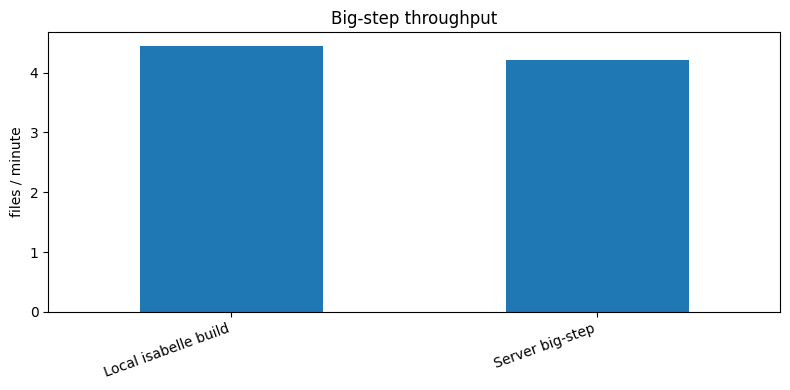

In [12]:
ax = bigstep_table["files_per_min_mean"].plot(kind="bar", figsize=(8, 4), title="Big-step throughput")
ax.set_ylabel("files / minute")
ax.set_xlabel("")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


## Small-step summary

For small-step evaluation, the most useful metrics are:
- total wall-clock time for the benchmark,
- files per minute,
- mean startup time per file,
- mean step elapsed time,
- P95 step elapsed time,
- median wall time per file.

The table below keeps the main local baselines and the main server configurations.


In [13]:
smallstep = repeated[repeated["family"] == "smallstep"].copy()

smallstep_metrics = [
    "total_wall_time_sec",
    "files_per_minute",
    "mean_startup_sec_per_file",
    "mean_step_elapsed_sec",
    "p95_step_elapsed_sec",
    "median_wall_time_sec_per_file",
]

smallstep_summary = aggregate_runs(smallstep, ["config_label"], smallstep_metrics)
display(smallstep_summary)


total_wall_time_sec                                                        files_per_minute                                                \
                                                       mean       std       median          min          max count             mean       std    median       min       max count   
config_label                                                                                                                                                                        
Local IsabelleGym                                444.430883  6.282412   443.369637   435.746325   451.440908     5         2.160412  0.030628  2.165236  2.126524  2.203117     5   
QIsabelle                                       2196.600765  6.856555  2192.980140  2192.067791  2208.164828     5         0.437042  0.001360  0.437760  0.434750  0.437943     5   
Server small-step (1 worker, reuse off)          333.820551  3.316128   334.090146   329.973664   337.758154     5         2.876024  0.028578  2.873476  2.842270  2.909323     5   
Server small-step (1 worker, reuse on)           313.144466  2.757889   312.312924   309.650734   317.049748     5         3.065868  0.026954  3.073840  3.027916  3.100267     5   
Server small-step (4 workers, reuse on)          129.074962  1.259436   129.331612   127.424640   130.343803     5         7.438107  0.072764  7.422779  7.365137  7.533865     5   
Server small-step (8 workers, reuse on)          125.497165  1.862734   124.446709   123.965494   128.383339     5         7.650910  0.112390  7.714145  7.477606  7.744090     5   

                                        mean_startup_sec_per_file                                                  mean_step_elapsed_sec                                                \
                                                             mean       std     median        min        max count                  mean       std    median       min       max count   
config_label                                                                                                                                                                             
Local IsabelleGym                                       10.495591  0.324564  10.429617  10.058859  10.893471     5              0.128741  0.001134  0.129203  0.127170  0.129699     5   
QIsabelle                                                7.690856  0.144154   7.655011   7.525926   7.843812     5              2.077256  0.006612  2.073645  2.073013  2.088473     5   
Server small-step (1 worker, reuse off)                  4.766464  0.102509   4.800950   4.655643   4.870461     5              0.237321  0.001678  0.237234  0.235484  0.239554     5   
Server small-step (1 worker, reuse on)                   3.858982  0.120177   3.834787   3.702836   4.024406     5              0.238223  0.000789  0.238130  0.237297  0.239412     5   
Server small-step (4 workers, reuse on)                  7.469649  0.144623   7.517214   7.287359   7.649850     5              0.242869  0.001014  0.242597  0.241731  0.244086     5   
Server small-step (8 workers, reuse on)                 18.193214  0.653856  17.923893  17.629527  19.009106     5              0.261329  0.004595  0.259621  0.258268  0.269456     5   

                                        p95_step_elapsed_sec                                               median_wall_time_sec_per_file                                                      
                                                        mean       std    median       min       max count                          mean       std      median         min         max count  
config_label                                                                                                                                                                                  
Local IsabelleGym                                   0.175505  0.025219  0.169746  0.151917  0.202069     5                     18.030490  0.232619   18.057853   1

In [14]:
smallstep_table = smallstep.groupby("config_label").agg(
    runs=("run_id", "count"),
    total_wall_mean=("total_wall_time_sec", "mean"),
    files_per_min_mean=("files_per_minute", "mean"),
    startup_mean=("mean_startup_sec_per_file", "mean"),
    step_mean=("mean_step_elapsed_sec", "mean"),
    step_p95_mean=("p95_step_elapsed_sec", "mean"),
    theory_median_mean=("median_wall_time_sec_per_file", "mean"),
).sort_values("total_wall_mean")

display(smallstep_table.round(3))


,runs,total_wall_mean,files_per_min_mean,startup_mean,step_mean,step_p95_mean,theory_median_mean
config_label,,,,,,,
"Server small-step (8 workers, reuse on)",5,125.497,7.651,18.193,0.261,0.291,38.052
"Server small-step (4 workers, reuse on)",5,129.075,7.438,7.470,0.243,0.240,22.066
"Server small-step (1 worker, reuse on)",5,313.144,3.066,3.859,0.238,0.205,10.379
"Server small-step (1 worker, reuse off)",5,333.821,2.876,4.766,0.237,0.203,11.529
Local IsabelleGym,5,444.431,2.160,10.496,0.129,0.176,18.030
QIsabelle,5,2196.601,0.437,7.691,2.077,2.077,100.435


In [15]:
# Latency-oriented view
latency_view = smallstep_table[["startup_mean", "step_mean", "step_p95_mean", "theory_median_mean"]].sort_values("step_mean")
display(latency_view.round(3))


,startup_mean,step_mean,step_p95_mean,theory_median_mean
config_label,,,,
Local IsabelleGym,10.496,0.129,0.176,18.030
"Server small-step (1 worker, reuse off)",4.766,0.237,0.203,11.529
"Server small-step (1 worker, reuse on)",3.859,0.238,0.205,10.379
"Server small-step (4 workers, reuse on)",7.470,0.243,0.240,22.066
"Server small-step (8 workers, reuse on)",18.193,0.261,0.291,38.052
QIsabelle,7.691,2.077,2.077,100.435


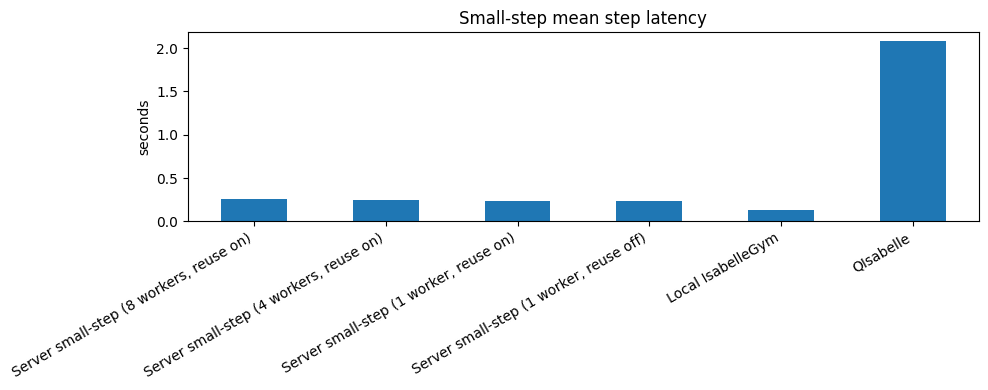

In [16]:
ax = smallstep_table["step_mean"].plot(kind="bar", figsize=(10, 4), title="Small-step mean step latency")
ax.set_ylabel("seconds")
ax.set_xlabel("")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


## Server-side small-step scalability and reuse

The next tables isolate the server-side runs to show:
- throughput scaling with worker count,
- the effect of `reuse=true` versus `reuse=false`.


In [17]:
server_small = smallstep[smallstep["config"].str.startswith("worker_")].copy()

scaling = server_small.groupby(["workers", "reuse"]).agg(
    runs=("run_id", "count"),
    total_wall_mean=("total_wall_time_sec", "mean"),
    files_per_min_mean=("files_per_minute", "mean"),
    startup_mean=("mean_startup_sec_per_file", "mean"),
    step_mean=("mean_step_elapsed_sec", "mean"),
    theory_median_mean=("median_wall_time_sec_per_file", "mean"),
).sort_index()

display(scaling.round(3))


runs  total_wall_mean  files_per_min_mean  startup_mean  step_mean  theory_median_mean
workers reuse                                                                                        
1.0     False     5          333.821               2.876         4.766      0.237              11.529
        True      5          313.144               3.066         3.859      0.238              10.379
4.0     True      5          129.075               7.438         7.470      0.243              22.066
8.0     True      5          125.497               7.651        18.193      0.261              38.052

In [18]:
reuse_impact = server_small[server_small["workers"] == 1].groupby("reuse").agg(
    runs=("run_id", "count"),
    total_wall_mean=("total_wall_time_sec", "mean"),
    files_per_min_mean=("files_per_minute", "mean"),
    startup_mean=("mean_startup_sec_per_file", "mean"),
    step_mean=("mean_step_elapsed_sec", "mean"),
).sort_index()

display(reuse_impact.round(3))


,runs,total_wall_mean,files_per_min_mean,startup_mean,step_mean
reuse,,,,,
False,5,333.821,2.876,4.766,0.237
True,5,313.144,3.066,3.859,0.238


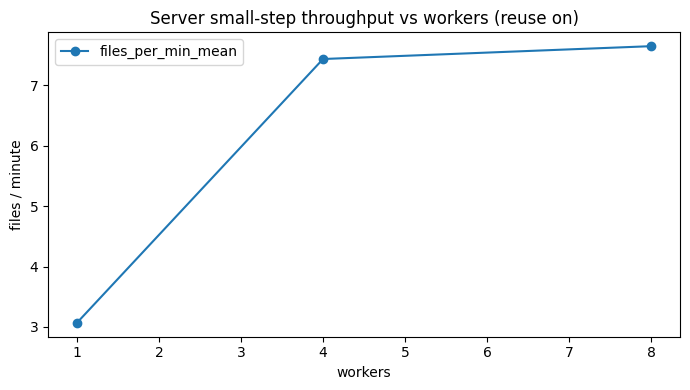

In [19]:
reuse_true = scaling.reset_index().query("reuse == True").sort_values("workers")
ax = reuse_true.plot(x="workers", y="files_per_min_mean", marker="o", figsize=(7, 4), title="Server small-step throughput vs workers (reuse on)")
ax.set_ylabel("files / minute")
ax.set_xlabel("workers")
plt.tight_layout()
plt.show()


## Suggested metrics to report in the dissertation

### Big-step
Use these as the main reported numbers:
1. **Total wall-clock time** for the corpus.
2. **Files per minute**.
3. **Mean wall time per file**.
4. **Median wall time per file**.
5. **Client overhead per file** for the server big-step path.

### Small-step
Use these as the main reported numbers:
1. **Total wall-clock time** for the benchmark.
2. **Files per minute**.
3. **Mean startup time per file**.
4. **Mean step elapsed time**.
5. **P95 step elapsed time**.
6. **Median wall time per file**.

### Scalability / reuse
For the server-side small-step discussion, focus on:
1. **Files per minute** as worker count changes.
2. **Total wall-clock time** as worker count changes.
3. **Mean startup time per file** for reuse on/off.
4. **Mean step elapsed time** to show whether command latency stays stable.


In [20]:
# Convenience exports for use outside the notebook
export_dir = BASE / "analysis_exports"
export_dir.mkdir(exist_ok=True)

bigstep_table.round(6).to_csv(export_dir / "bigstep_summary.csv")
smallstep_table.round(6).to_csv(export_dir / "smallstep_summary.csv")
scaling.round(6).to_csv(export_dir / "server_smallstep_scaling.csv")
summary_df.to_csv(export_dir / "all_runs_manifest.csv", index=False)

print(f"Wrote CSV exports to: {export_dir}")


Wrote CSV exports to: c:\Users\winst\GitHub\IsabelleGym\evaluation\analysis_exports
